<a href="https://colab.research.google.com/github/haniminsyirah/churn-profit-optimization/blob/main/TELCO_CHURN_PREDICTION.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## IMPORT LIBRARIES

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report, confusion_matrix
from sklearn.ensemble import RandomForestClassifier

import warnings
warnings.filterwarnings("ignore")

## LOAD DATASET

In [ ]:
df = pd.read_excel("Telco_customer_churn.xlsx")
df.head()

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,...,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,...,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices


In [ ]:
# Shape of dataset
df.shape
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   object 
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   object 
 3   State              7043 non-null   object 
 4   City               7043 non-null   object 
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   object 
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   object 
 10  Senior Citizen     7043 non-null   object 
 11  Partner            7043 non-null   object 
 12  Dependents         7043 non-null   object 
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   object 
 15  Multiple Lines     7043 non-null   object 
 16  Internet Service   7043 



*   Total Charges is stored as object (should be numeric).
*   Churn Reason column has missing values. This is expected, because only customers who churned have a reason. So this is NOT a problem.


*   CustomerID,Count,Country,State,City,
    Zip Code,Lat Long,Latitude,Longitude,
    Churn Label,Churn Score,CLTV and Churn Reason have NO predictive value






In [ ]:
df.duplicated().sum()

np.int64(0)

This dataset doesn't have any null or duplicate values

## DATA CLEANING

In [ ]:
df['Total Charges'] = pd.to_numeric(df['Total Charges'], errors='coerce')

In [ ]:
df['Total Charges'].isnull().sum()

np.int64(11)

In [ ]:
df = df.dropna(subset=['Total Charges'])

In [ ]:
cols_to_drop = [
    "CustomerID","Count","Country","State","City",
    "Zip Code","Lat Long","Latitude","Longitude",
    "Churn Label","Churn Score","CLTV","Churn Reason"
]

df = df.drop(columns=cols_to_drop, errors='ignore')

# Rename target column
df.rename(columns={"Churn Value": "Churn"}, inplace=True)

# Fix Total Charges datatype
df["Total Charges"] = pd.to_numeric(df["Total Charges"], errors="coerce")
df["Total Charges"].fillna(df["Total Charges"].median(), inplace=True)


## EDA

### BASIC DATA OVERVIEW

Churn Rate: 26.578498293515356

Summary Statistics:
       Tenure Months  Monthly Charges  Total Charges        Churn
count    7032.000000      7032.000000    7032.000000  7032.000000
mean       32.421786        64.798208    2283.300441     0.265785
std        24.545260        30.085974    2266.771362     0.441782
min         1.000000        18.250000      18.800000     0.000000
25%         9.000000        35.587500     401.450000     0.000000
50%        29.000000        70.350000    1397.475000     0.000000
75%        55.000000        89.862500    3794.737500     1.000000
max        72.000000       118.750000    8684.800000     1.000000

Churn Distribution:
Churn
0    5163
1    1869
Name: count, dtype: int64


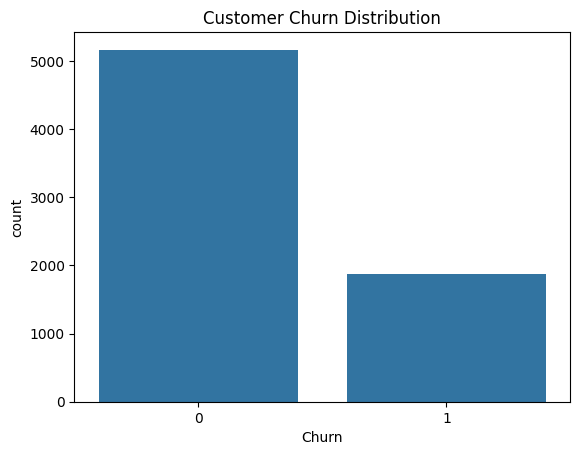

In [ ]:
print("Churn Rate:", df["Churn"].mean()*100)
print("\nSummary Statistics:")
print(df.describe())

# Target distribution
print("\nChurn Distribution:")
print(df["Churn"].value_counts())


sns.countplot(x="Churn", data=df)
plt.title("Customer Churn Distribution")
plt.show()



*  A churn rate above 25% is considered high for telecom companies, indicating significant customer loss.

*  Understanding the drivers of churn is critical because customer acquisition costs are significantly higher than retention costs.





### EDA 2: NUMERIC FEATURES



*   Understand customer behavior
*   Find patterns linked to churn
*   Identify important predictors





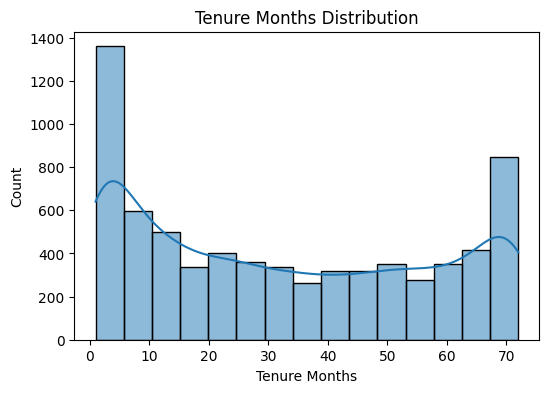

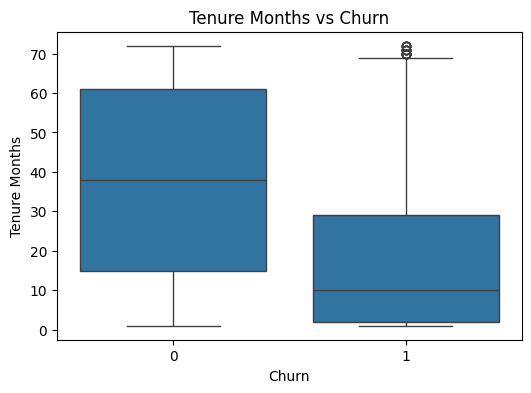

In [ ]:
numeric_cols = ["Tenure Months"]

for col in numeric_cols:

    plt.figure(figsize=(6,4))
    sns.histplot(df[col], kde=True)
    plt.title(f"{col} Distribution")
    plt.show()

    plt.figure(figsize=(6,4))
    sns.boxplot(x="Churn", y=col, data=df)
    plt.title(f"{col} vs Churn")
    plt.show()

The boxplot reveals that customers who churn (1) have a much lower median tenure (around 10 months) compared to those who stay (around 38 months).

Most customers leave early:  

*   Many customers churn in the first year. In fact,those who leave usually stay only about 10 months.
*   Customers who stay have a much longer tenure (around 38 months). This makes tenure one of the strongest factors in predicting churn.
*   Two types of customers
    - Some leave quickly (within 0–5 months)
    - Others stay for a long time (70+ months)
*   If a customer stays beyond 30 months, they are much less likely to leave.


Strategy:

*   Focus on new customers. Since many leave early, the company should improve the first-year experience (e.g., better onboarding, rewards) to keep them longer.

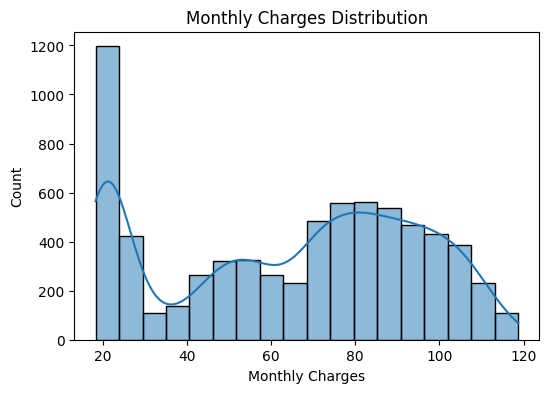

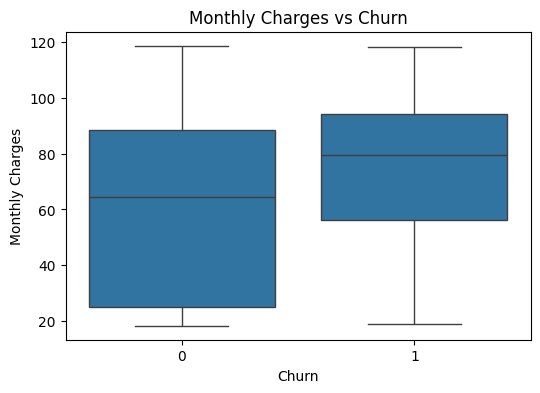

In [ ]:
numeric_cols = ["Monthly Charges"]

for col in numeric_cols:

    plt.figure(figsize=(6,4))
    sns.histplot(df[col], kde=True)
    plt.title(f"{col} Distribution")
    plt.show()

    plt.figure(figsize=(6,4))
    sns.boxplot(x="Churn", y=col, data=df)
    plt.title(f"{col} vs Churn")
    plt.show()



* Higher bills = higher churn: Customers who leave usually pay more (~$80) than those who stay (~$65)


* Low-cost customers stay longer: There is a large group paying around $20, and they are less likely to churn.

*   Churn increases at high prices: When monthly charges reach $70-$100, the risk of churn becomes higher. These customers may expect better service or switch to competitors.


Strategy:

*   Watch high-paying new customers: Customers with high monthly charges and low tenure are the highest-risk group.
*   Focus on better service, offers, or discounts early to retain them.




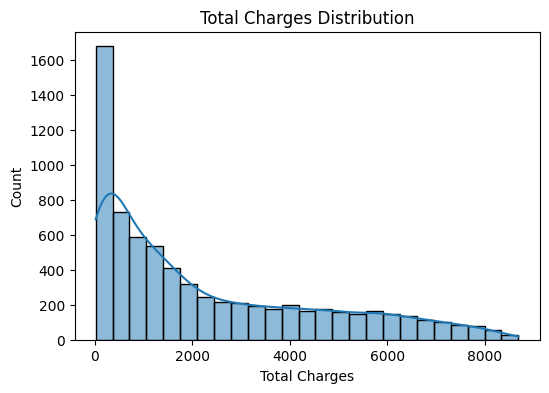

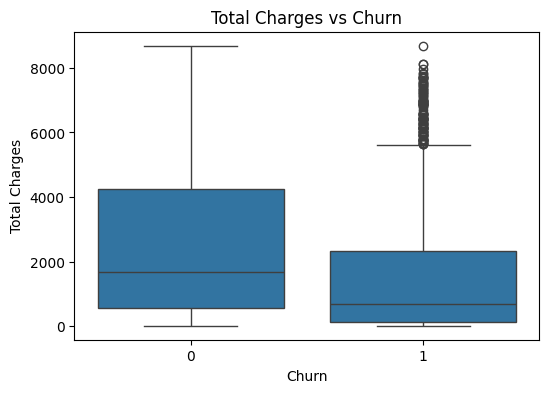

In [ ]:
numeric_cols = ["Total Charges"]

for col in numeric_cols:

    plt.figure(figsize=(6,4))
    sns.histplot(df[col], kde=True)
    plt.title(f"{col} Distribution")
    plt.show()

    plt.figure(figsize=(6,4))
    sns.boxplot(x="Churn", y=col, data=df)
    plt.title(f"{col} vs Churn")
    plt.show()



*   Low total spend = high churn: Customers who churn have low total charges because they leave early, not because they spend less.

*  Most customers are low spenders: Many customers fall within the $0–$1,000 range, showing that a large portion does not stay long.
*   Loyal customers generate more value: Customers who stay longer accumulate higher total charges (up to $8,000), making them more valuable.

*   Data is skewed: Most values are concentrated at the lower end, so log transformation may be needed for certain models



### EDA 3: CATEGORICAL FEATURE CHURN ANALYSIS


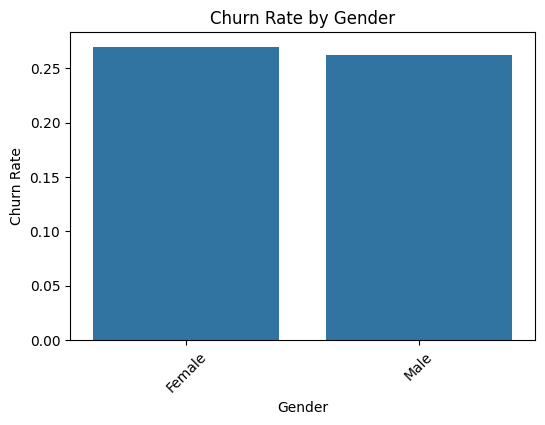


Churn % by Gender
Gender
Female    26.96
Male      26.20
Name: Churn, dtype: float64


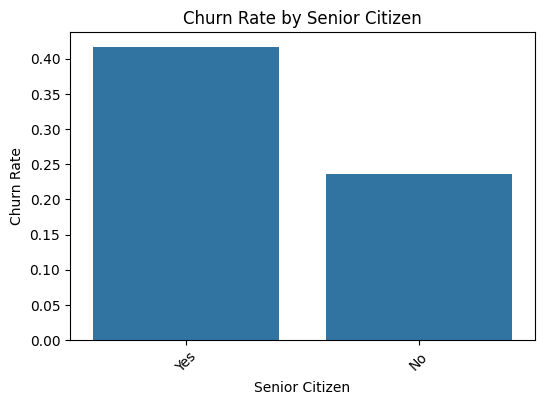


Churn % by Senior Citizen
Senior Citizen
No     23.65
Yes    41.68
Name: Churn, dtype: float64


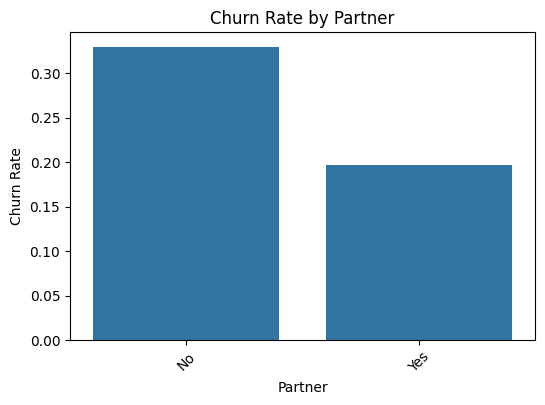


Churn % by Partner
Partner
No     32.98
Yes    19.72
Name: Churn, dtype: float64


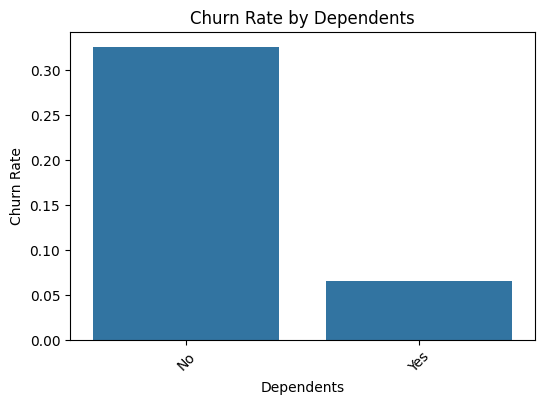


Churn % by Dependents
Dependents
No     32.58
Yes     6.54
Name: Churn, dtype: float64


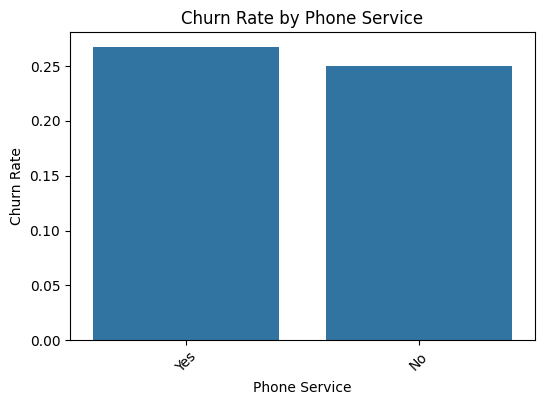


Churn % by Phone Service
Phone Service
No     25.00
Yes    26.75
Name: Churn, dtype: float64


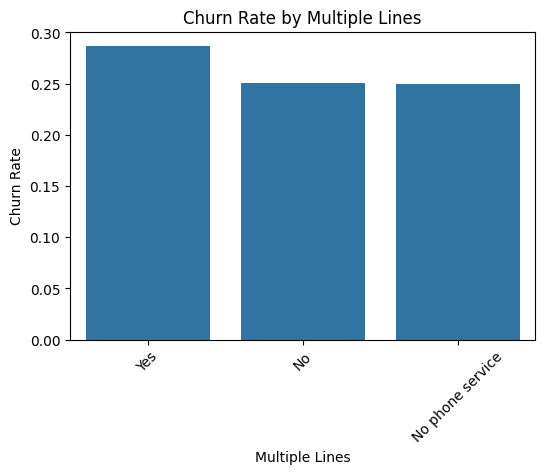


Churn % by Multiple Lines
Multiple Lines
No                  25.08
No phone service    25.00
Yes                 28.65
Name: Churn, dtype: float64


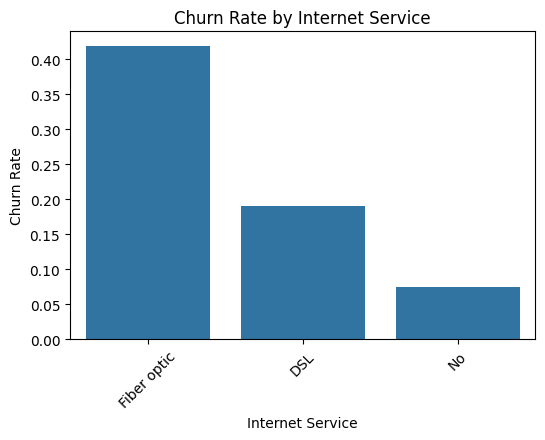


Churn % by Internet Service
Internet Service
DSL            19.00
Fiber optic    41.89
No              7.43
Name: Churn, dtype: float64


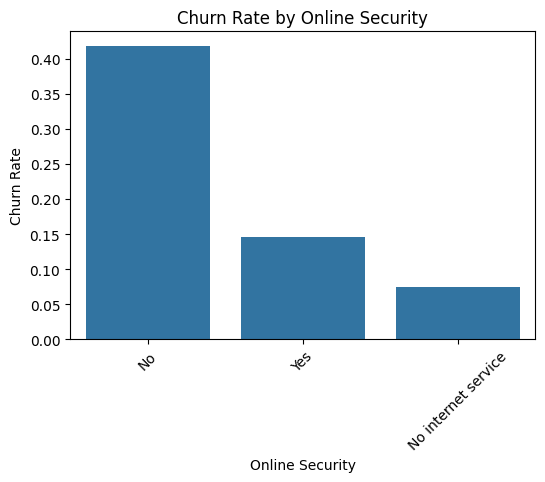


Churn % by Online Security
Online Security
No                     41.78
No internet service     7.43
Yes                    14.64
Name: Churn, dtype: float64


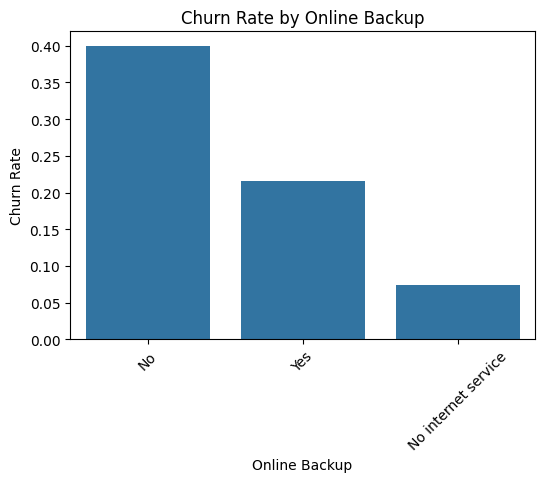


Churn % by Online Backup
Online Backup
No                     39.94
No internet service     7.43
Yes                    21.57
Name: Churn, dtype: float64


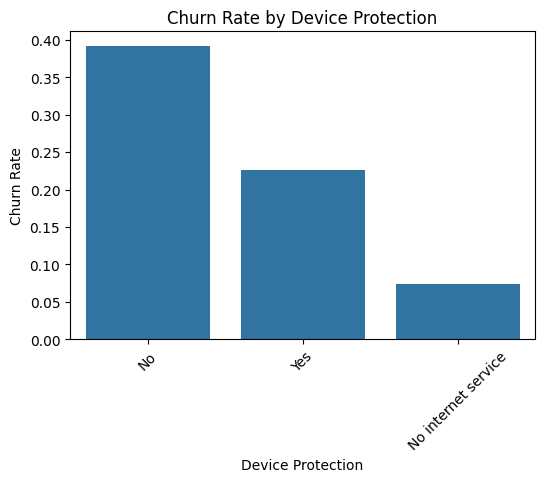


Churn % by Device Protection
Device Protection
No                     39.14
No internet service     7.43
Yes                    22.54
Name: Churn, dtype: float64


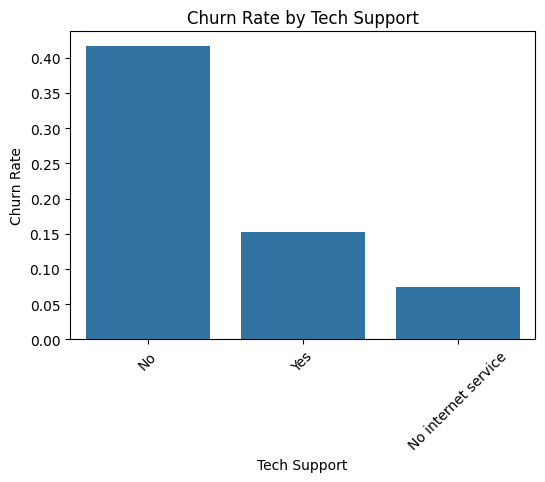


Churn % by Tech Support
Tech Support
No                     41.65
No internet service     7.43
Yes                    15.20
Name: Churn, dtype: float64


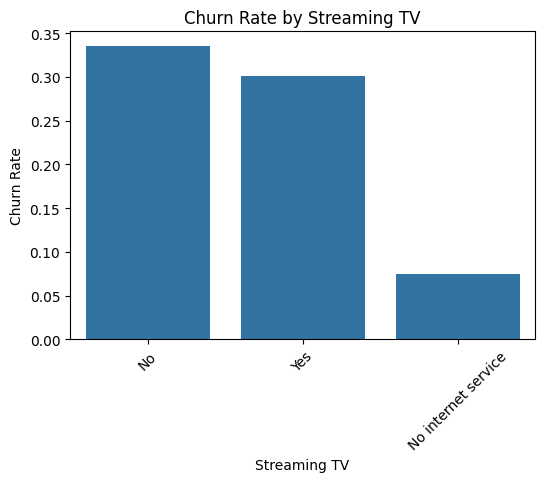


Churn % by Streaming TV
Streaming TV
No                     33.54
No internet service     7.43
Yes                    30.11
Name: Churn, dtype: float64


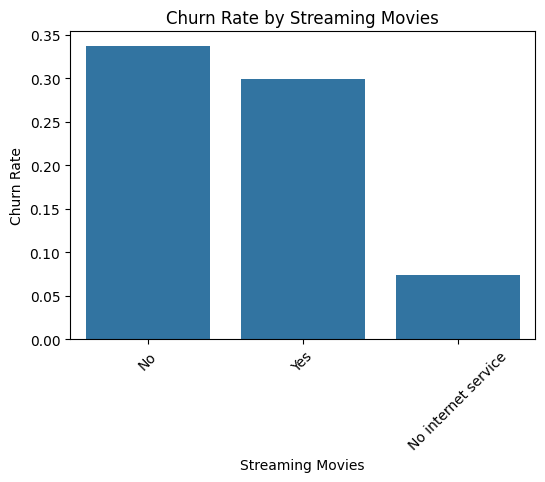


Churn % by Streaming Movies
Streaming Movies
No                     33.73
No internet service     7.43
Yes                    29.95
Name: Churn, dtype: float64


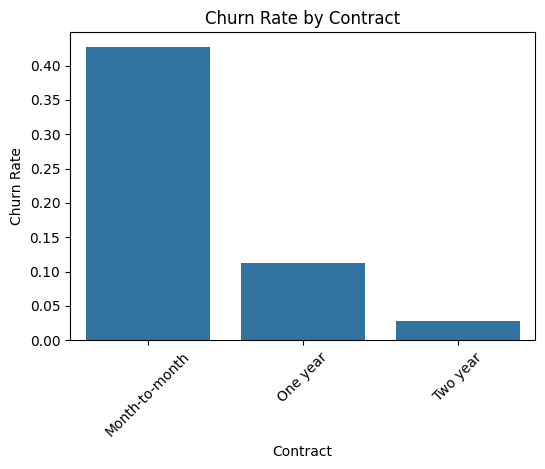


Churn % by Contract
Contract
Month-to-month    42.71
One year          11.28
Two year           2.85
Name: Churn, dtype: float64


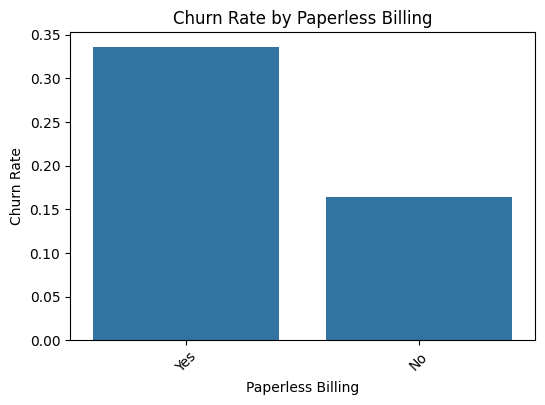


Churn % by Paperless Billing
Paperless Billing
No     16.38
Yes    33.59
Name: Churn, dtype: float64


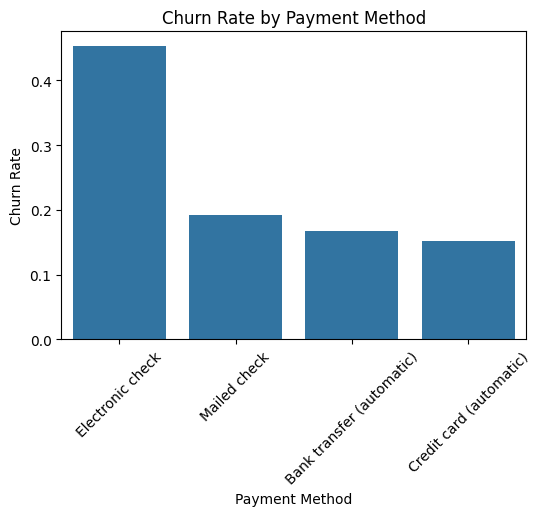


Churn % by Payment Method
Payment Method
Bank transfer (automatic)    16.73
Credit card (automatic)      15.25
Electronic check             45.29
Mailed check                 19.20
Name: Churn, dtype: float64


In [ ]:
cat_cols = df.select_dtypes(include="object").columns

for col in cat_cols:

    plt.figure(figsize=(6,4))

    churn_rate = df.groupby(col)["Churn"].mean().sort_values(ascending=False)

    sns.barplot(
        x=churn_rate.index,
        y=churn_rate.values
    )

    plt.xticks(rotation=45)
    plt.title(f"Churn Rate by {col}")
    plt.ylabel("Churn Rate")
    plt.show()

    print("\nChurn % by", col)
    print((df.groupby(col)["Churn"].mean()*100).round(2))

Overall Key Takeaways

*  High-risk customers:
   - Month-to-month contracts
   - No partner / no dependents
   - Electronic check users
   - No support services
   - Fiber optic users

*  Low-risk customers:
   - Long-term contracts
   - Customers with support services
   - Automatic payment users

### EDA 4: CORRELATION ANALYSIS

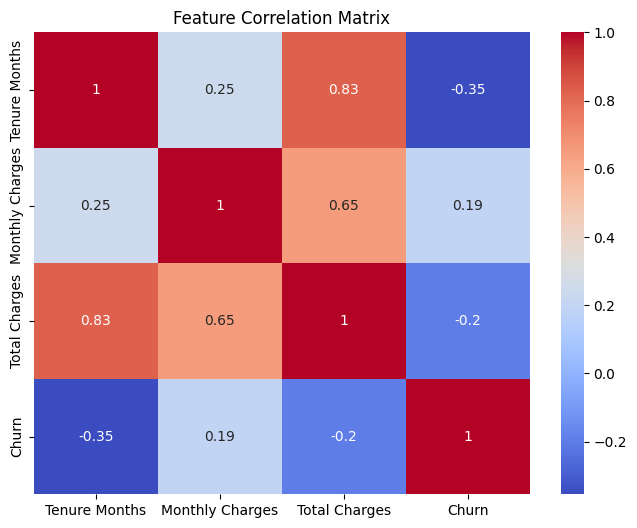

In [ ]:
numeric_df = df.select_dtypes(include=["int64","float64"])

plt.figure(figsize=(8,6))
sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm")
plt.title("Feature Correlation Matrix")
plt.show()

Correlation Matrix Insight:

*   Tenure shows the strongest relationship with churn (negative correlation), meaning longer-term customers are less likely to leave.


*    Monthly charges have a weaker positive relationship, indicating higher costs may increase churn risk.
*   A high correlation between tenure and total charges suggests redundancy, so one of these features can be removed to improve model performance.



### EDA 5: IDENTIFY STRONGEST CHURN DRIVERS



In [ ]:
churn_summary = []

for col in cat_cols:

    rates = df.groupby(col)["Churn"].mean()

    if len(rates) > 1:

        diff = rates.max() - rates.min()

        churn_summary.append({
            "Feature": col,
            "Max_Churn": rates.max(),
            "Min_Churn": rates.min(),
            "Difference": diff
        })

churn_summary = pd.DataFrame(churn_summary)

churn_summary = churn_summary.sort_values(
    "Difference",
    ascending=False
)

print("\nTop Churn Drivers Based on Difference:")
print(churn_summary.head(10))


Top Churn Drivers Based on Difference:
              Feature  Max_Churn  Min_Churn  Difference
13           Contract   0.427097   0.028487    0.398610
6    Internet Service   0.418928   0.074342    0.344586
7     Online Security   0.417787   0.074342    0.343445
10       Tech Support   0.416475   0.074342    0.342133
8       Online Backup   0.399417   0.074342    0.325075
9   Device Protection   0.391403   0.074342    0.317061
15     Payment Method   0.452854   0.152531    0.300323
12   Streaming Movies   0.337289   0.074342    0.262947
11       Streaming TV   0.335351   0.074342    0.261009
3          Dependents   0.325758   0.065432    0.260325


### EDA 6: FINAL KEY CHURN DRIVERS


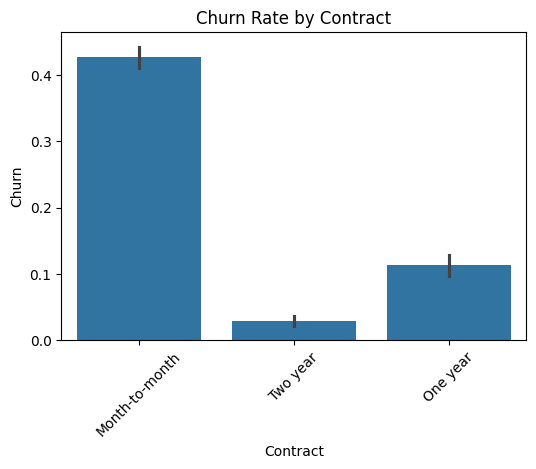

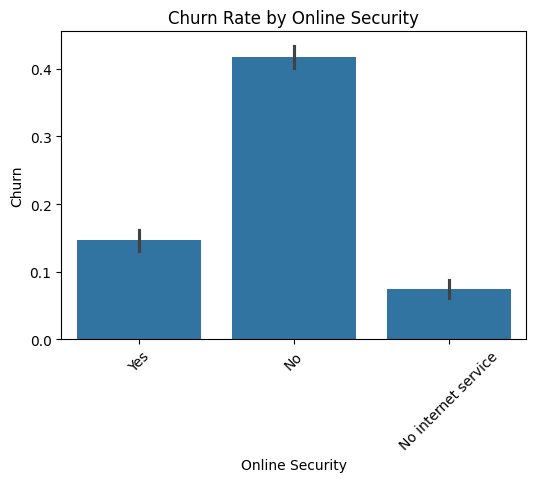

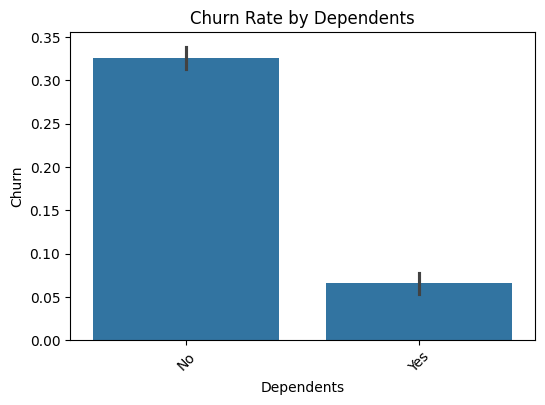

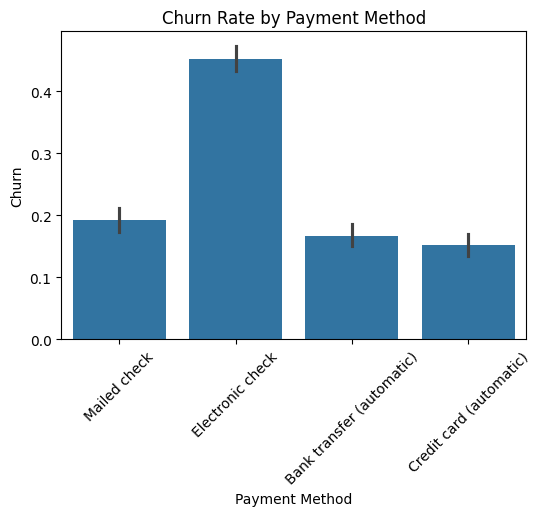

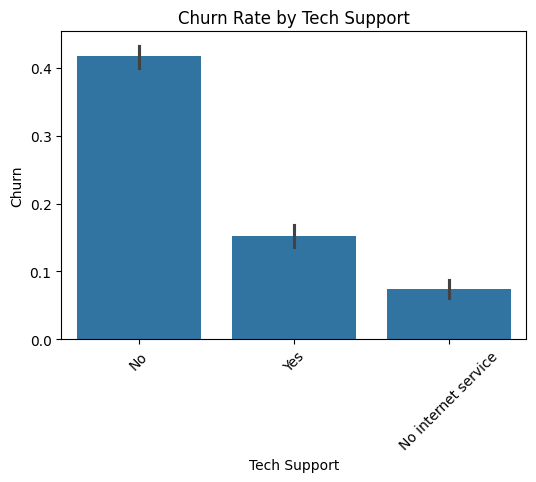

In [ ]:
key_features = [
    "Contract",
    "Online Security",
    "Dependents",
    "Payment Method",
    "Tech Support"
]

for col in key_features:

    plt.figure(figsize=(6,4))

    sns.barplot(
        data=df,
        x=col,
        y="Churn"
    )

    plt.title(f"Churn Rate by {col}")
    plt.xticks(rotation=45)
    plt.show()

### EDA 7: TENURE SEGMENTATION

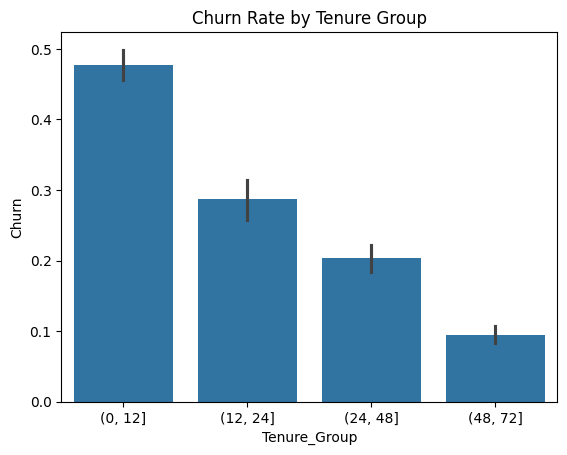

In [ ]:
df["Tenure_Group"] = pd.cut(
    df["Tenure Months"],
    bins=[0,12,24,48,72]
)

sns.barplot(
    data=df,
    x="Tenure_Group",
    y="Churn"
)

plt.title("Churn Rate by Tenure Group")
plt.show()


*   Customers without long-term commitments are more likely to leave the service
*   Longer contracts act as a natural retention mechanism, suggesting that encouraging customers to upgrade to annual or multi-year plans could significantly reduce churn
.

## ENCODING


In [ ]:

df_encoded = pd.get_dummies(df, drop_first=False)

X = df_encoded.drop("Churn", axis=1)
y = df_encoded["Churn"]

## TRAIN TEST SPLIT


In [ ]:

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42
)

## MODEL TRAINING

In [ ]:
model = LogisticRegression(max_iter=1000, class_weight="balanced")
model.fit(X_train, y_train)

y_prob = model.predict_proba(X_test)[:,1]
threshold = 0.5
y_pred = (y_prob > threshold).astype(int)


## MODEL COMPARISON

In [ ]:

rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)
rf_prob = rf.predict_proba(X_test)[:,1]

print("\n=== MODEL COMPARISON ===")

print("\nLogistic Regression")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("AUC:", roc_auc_score(y_test, y_prob))

print("\nRandom Forest")
print("Accuracy:", accuracy_score(y_test, rf_pred))
print("AUC:", roc_auc_score(y_test, rf_prob))



=== MODEL COMPARISON ===

Logistic Regression
Accuracy: 0.7635071090047393
AUC: 0.8688984463693493

Random Forest
Accuracy: 0.7943127962085308
AUC: 0.8402511464506959


Both models perform well, but **Logistic Regression** is chosen as it is better for identifying and prioritizing high-risk customers.

## MODEL EVALUATION



=== LOGISTIC REGRESSION PERFORMANCE ===
Accuracy: 0.7635071090047393
AUC: 0.8688984463693493

Classification Report:

              precision    recall  f1-score   support

           0       0.91      0.74      0.82      1522
           1       0.55      0.82      0.66       588

    accuracy                           0.76      2110
   macro avg       0.73      0.78      0.74      2110
weighted avg       0.81      0.76      0.77      2110



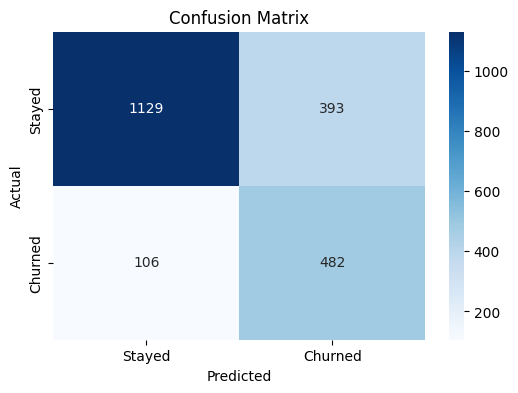


Confusion Matrix Breakdown:
True Negatives: 1129
False Positives: 393
False Negatives: 106
True Positives: 482


In [ ]:
print("\n=== LOGISTIC REGRESSION PERFORMANCE ===")

print("Accuracy:", accuracy_score(y_test, y_pred))
print("AUC:", roc_auc_score(y_test, y_prob))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues',
            xticklabels=['Stayed','Churned'],
            yticklabels=['Stayed','Churned'])

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

tn, fp, fn, tp = cm.ravel()

print("\nConfusion Matrix Breakdown:")
print("True Negatives:", tn)
print("False Positives:", fp)
print("False Negatives:", fn)
print("True Positives:", tp)


This model is well-suited for churn prediction, as it minimizes missed churn cases (low false negatives), which is crucial for business since losing customers is more costly than incorrectly flagging them.

## FEATURE IMPORTANCE


In [ ]:

importance = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_[0]
})

importance["Impact"] = np.where(
    importance["Coefficient"] > 0,
    "Increase Churn",
    "Decrease Churn"
)

importance["Abs"] = abs(importance["Coefficient"])

importance = importance.sort_values("Abs", ascending=False)

print("\nTop Churn Drivers:")
print(importance.head(10))


Top Churn Drivers:
                                   Feature  Coefficient          Impact  \
39                       Contract_Two year    -0.802262  Decrease Churn   
10                          Dependents_Yes    -0.801463  Decrease Churn   
37                 Contract_Month-to-month     0.716235  Increase Churn   
9                            Dependents_No     0.698890  Increase Churn   
47                   Tenure_Group_(12, 24]    -0.347972  Decrease Churn   
49                   Tenure_Group_(48, 72]     0.264000  Increase Churn   
44         Payment Method_Electronic check     0.249456  Increase Churn   
40                    Paperless Billing_No    -0.247802  Decrease Churn   
43  Payment Method_Credit card (automatic)    -0.237074  Decrease Churn   
16                    Internet Service_DSL    -0.220084  Decrease Churn   

         Abs  
39  0.802262  
10  0.801463  
37  0.716235  
9   0.698890  
47  0.347972  
49  0.264000  
44  0.249456  
40  0.247802  
43  0.237074  
16  

🔺 Factors that Increase Churn:

*   Month-to-month contracts are the strongest driver of churn, showing that customers without long-term commitment are more likely to leave.
*   Customers without dependents are more likely to churn, suggesting less attachment or responsibility.

*   Electronic check payment method is associated with higher churn, possibly due to less stable or manual payment behavior.

🔻 Factors that Decrease Churn

*   Two-year contracts significantly reduce churn, highlighting the importance of long-term commitments.
*   Automatic payment methods (credit card) reduce churn risk due to convenience and consistency.

*   Paperless billing (No) and DSL internet service are also linked to lower churn rates.


## CUSTOMER RISK SEGMENTATION


Risk_Level
Low Risk       1044
Medium Risk     571
High Risk       224
Name: count, dtype: int64


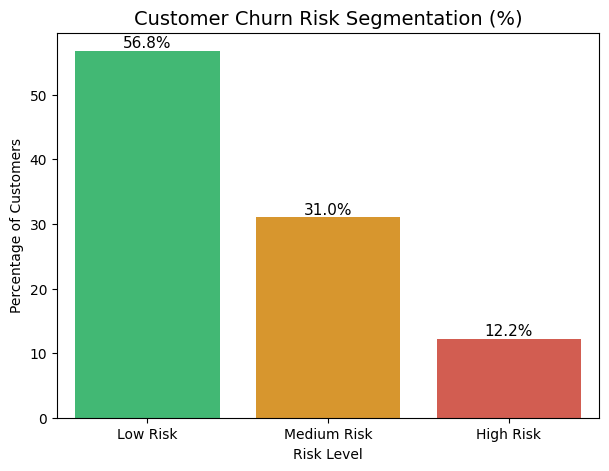

In [ ]:
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)
rf_probs = rf.predict_proba(X_test)[:,1]
df_test = X_test.copy()
df_test["Actual_Churn"] = y_test.values

df_test["Churn_Probability"] = rf_probs

df_test["Risk_Level"] = pd.cut(
    df_test["Churn_Probability"],
    bins=[0,0.3,0.7,1],
    labels=["Low Risk","Medium Risk","High Risk"]
)

risk_summary = df_test["Risk_Level"].value_counts()

print(risk_summary)
risk_percentage = (risk_summary / risk_summary.sum()) * 100



plt.figure(figsize=(7,5))

colors = {
    "Low Risk": "#2ecc71",
    "Medium Risk": "#f39c12",
    "High Risk": "#e74c3c"
}

sns.barplot(
    x=risk_percentage.index,
    y=risk_percentage.values,
    palette=[colors[x] for x in risk_percentage.index]
)

plt.title("Customer Churn Risk Segmentation (%)", fontsize=14)
plt.xlabel("Risk Level")
plt.ylabel("Percentage of Customers")

# add percentage labels
for i, v in enumerate(risk_percentage.values):
    plt.text(i, v + 0.5, f"{v:.1f}%", ha='center', fontsize=11)

plt.show()

## ROC CURVE


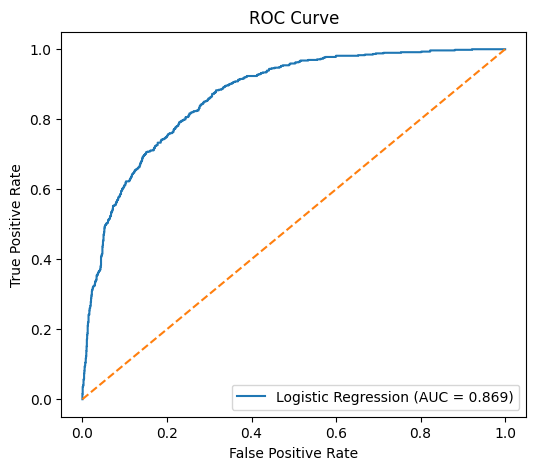

In [ ]:

from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label="Logistic Regression (AUC = %.3f)" % roc_auc_score(y_test, y_prob))
plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

## ROC CURVE COMPARISON


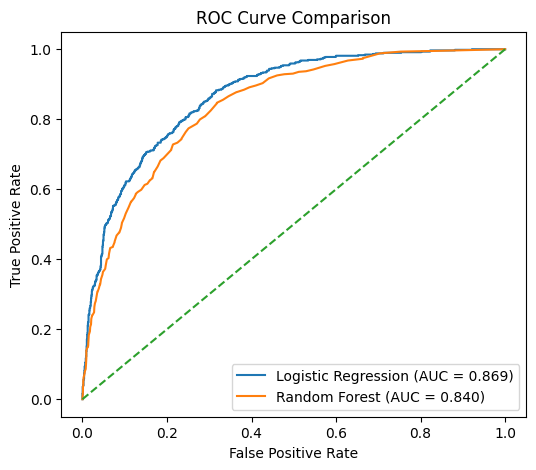

In [ ]:


lr_fpr, lr_tpr, _ = roc_curve(y_test, y_prob)
rf_fpr, rf_tpr, _ = roc_curve(y_test, rf_prob)

plt.figure(figsize=(6,5))

plt.plot(lr_fpr, lr_tpr, label="Logistic Regression (AUC = %.3f)" % roc_auc_score(y_test, y_prob))
plt.plot(rf_fpr, rf_tpr, label="Random Forest (AUC = %.3f)" % roc_auc_score(y_test, rf_prob))

plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()


*    Logistic Regression provides a higher true positive rate across most false positive thresholds, meaning it is better at correctly identifying customers at risk of churn.

*   Good balance between sensitivity and specificity: Both models maintain a strong trade-off, effectively detecting churners while keeping false alarms relatively controlled.

*    An AUC close to 0.87 indicates excellent predictive quality, making the model suitable for practical use in targeting retention strategies and prioritizing high-risk customers.

*  Conclusion:
   - Best-performing model: **Logistic Regression**




## PREDICTED CHURN (Q4 FORECAST)


In [ ]:

df_pred = df.copy()

full_prob = model.predict_proba(X)[:,1]

df_pred["Churn_Probability"] = full_prob
df_pred["Predicted_Churn"] = (full_prob > threshold).astype(int)

print("\n=== Q4 PREDICTED CHURN ===")

contract_pred = df_pred.groupby("Contract")["Predicted_Churn"].mean()*100
dependents_pred = df_pred.groupby("Dependents")["Predicted_Churn"].mean()*100
security_pred = df_pred.groupby("Online Security")["Predicted_Churn"].mean()*100

print("\nContract:\n", contract_pred)
print("\nDependents:\n", dependents_pred)
print("\nOnline Security:\n", security_pred)


=== Q4 PREDICTED CHURN ===

Contract:
 Contract
Month-to-month    69.858065
One year          11.141304
Two year           0.000000
Name: Predicted_Churn, dtype: float64

Dependents:
 Dependents
No     51.478197
Yes     5.246914
Name: Predicted_Churn, dtype: float64

Online Security:
 Online Security
No                     67.257649
No internet service     7.302632
Yes                    20.248139
Name: Predicted_Churn, dtype: float64


##REVENUE AT RISK

In [ ]:

df["Revenue_Risk"] = df["Monthly Charges"] * df["Churn"]

total_risk = df["Revenue_Risk"].sum()

print("\nTotal Revenue at Risk (Q4):", round(total_risk,2))


Total Revenue at Risk (Q4): 139130.85


## DECILE ANALYSIS


Decile Analysis:
Decile
0    0.000000
1    0.000000
2    0.000000
3    0.000000
4    0.000000
5    0.082504
6    1.000000
7    1.000000
8    1.000000
9    1.000000
Name: Predicted_Churn, dtype: float64


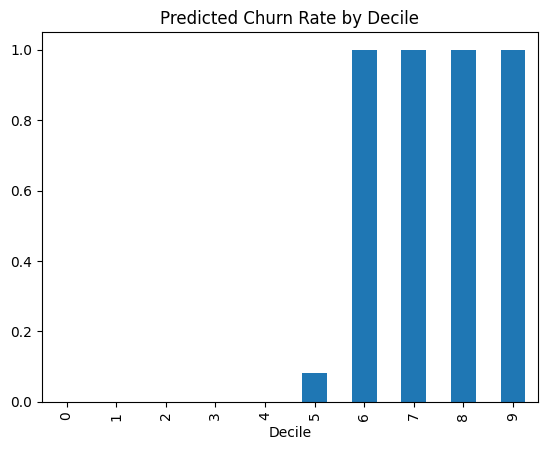

In [ ]:

df_pred["Decile"] = pd.qcut(df_pred["Churn_Probability"], 10, labels=False)

decile = df_pred.groupby("Decile")["Predicted_Churn"].mean()

print("\nDecile Analysis:")
print(decile)

decile.plot(kind="bar")
plt.title("Predicted Churn Rate by Decile")
plt.show()



* The model shows clear concentration of churn in the highest-risk segments, particularly the top 40% of deciles (Deciles 6–9), where churn levels become extremely high.

* A distinct breakpoint appears around Decile 5, indicating the model successfully separates low-risk and high-risk customers into two meaningful groups.

*  Focusing retention efforts on Deciles 6–9 allows the business to capture most churn-prone customers while using significantly fewer resources.

* The results support a targeted strategy where over half of the customer base (lower deciles) requires minimal or no intervention, reducing unnecessary campaign spending.

*  The sharp shift in churn rates across deciles indicates strong ranking power, meaning the model reliably prioritizes customers from lowest to highest risk.



## STRATEGY SIMULATION


In [ ]:


df_strategy = df_pred.copy()

# Assume retention campaign reduces churn probability by 20%
df_strategy["Adjusted_Prob"] = df_strategy["Churn_Probability"] * 0.8
df_strategy["Strategized_Churn"] = (df_strategy["Adjusted_Prob"] > threshold).astype(int)

print("\n=== STRATEGIZED CHURN RATE ===")

contract_strategy = df_strategy.groupby("Contract")["Strategized_Churn"].mean()*100
dependents_strategy = df_strategy.groupby("Dependents")["Strategized_Churn"].mean()*100
security_strategy = df_strategy.groupby("Online Security")["Strategized_Churn"].mean()*100

print("\nContract:\n", contract_strategy)
print("\nDependents:\n", dependents_strategy)
print("\nOnline Security:\n", security_strategy)


=== STRATEGIZED CHURN RATE ===

Contract:
 Contract
Month-to-month    57.032258
One year           2.241848
Two year           0.000000
Name: Strategized_Churn, dtype: float64

Dependents:
 Dependents
No     40.964523
Yes     1.604938
Name: Strategized_Churn, dtype: float64

Online Security:
 Online Security
No                     56.734344
No internet service     0.921053
Yes                    12.158809
Name: Strategized_Churn, dtype: float64


## IMPACT ANALYSIS


In [ ]:

print("\n=== IMPACT ANALYSIS ===")

before = df_pred["Predicted_Churn"].mean()
after = df_strategy["Strategized_Churn"].mean()

print("Overall Reduction (%):", (before-after)*100)



=== IMPACT ANALYSIS ===
Overall Reduction (%): 8.930602957906714


## PREPARE DATA FOR POWER BI


In [ ]:

df_model = df_encoded.copy()

df_model["Churn_Probability"] = full_prob
df_model["Predicted_Churn"] = (full_prob > threshold).astype(int)
df_model["Strategized_Churn"] = df_strategy["Strategized_Churn"].values

# Revenue metrics
df_model["Revenue_At_Risk"] = np.where(
    df_model["Predicted_Churn"] == 1,
    df["Monthly Charges"],
    0
)

df_model["Is_Saved"] = np.where(
    (df_model["Predicted_Churn"] == 1) &
    (df_model["Strategized_Churn"] == 0),
    1,
    0
)

df_model["Revenue_Saved"] = df_model["Is_Saved"] * df["Monthly Charges"]

# Human readable columns for Power BI
df_model["Contract_Type"] = df["Contract"]
df_model["Internet_Service"] = df["Internet Service"]
df_model["Dependents_Status"] = df["Dependents"]
df_model["Security_Status"] = df["Online Security"]
df_model["Tenure_Group"] = df["Tenure_Group"].astype(str)

# Feature importance export
importance_df = importance.copy()
importance_df.rename(columns={"Abs":"Abs_Score"}, inplace=True)

# Executive KPI table
summary_kpis = pd.DataFrame({

    "Metric":[
        "Total Revenue at Risk ($)",
        "Total Revenue Saved ($)",
        "Baseline Churn Rate (%)",
        "Strategized Churn Rate (%)",
        "Overall Reduction (%)"
    ],

    "Value":[
        df_model["Revenue_At_Risk"].sum(),
        df_model["Revenue_Saved"].sum(),
        df_model["Predicted_Churn"].mean()*100,
        df_model["Strategized_Churn"].mean()*100,
        (df_model["Predicted_Churn"].mean() -
         df_model["Strategized_Churn"].mean())*100
    ]

})



In [ ]:
with pd.ExcelWriter("Telco_Dashboard_Final_Data.xlsx") as writer:

    df_model.to_excel(writer,
                      sheet_name="Main_Dashboard_Data",
                      index=False)

    importance_df.to_excel(writer,
                           sheet_name="Feature_Importance",
                           index=False)

    summary_kpis.to_excel(writer,
                          sheet_name="Executive_KPIs",
                          index=False)

print("File exported: Telco_Dashboard_Final_Data.xlsx")


✅ DATA READY FOR POWER BI
File exported: Telco_Dashboard_Final_Data.xlsx
